# dependencies

In [1]:
import math
import numpy as np
import pandas as pd
import os
import pathlib
from dotenv import load_dotenv

In [2]:
from huggingface_hub import login, logout
from transformers import Wav2Vec2Processor, Wav2Vec2ForCTC, AutoProcessor, AutoModelForCTC, pipeline
import datasets
from datasets import load_dataset, Audio
import torch

/home/peter/miniconda3/envs/thesis/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
device = "cpu" #torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cpu


# log in

In [4]:
load_dotenv()
from huggingface_hub import login, logout
secret_value_0 = os.getenv("HF_KEY")

login(secret_value_0)

# load data

In [5]:
# determine project root
PROJECT_ROOT = pathlib.Path('.').resolve()

while not (PROJECT_ROOT / '.git').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

CANONICAL_DATA_PATH = PROJECT_ROOT / 'data' / 'teanglann' / 'teangl_phon_dataset'
PAIRED_DATA_PATH = PROJECT_ROOT / 'data' / 'synthetic' / 'paired'
SYNTHETIC_AUDIO_DIR = PROJECT_ROOT / 'data' / 'synthetic' / 'audio'

In [6]:
from datasets import load_from_disk

# paired dataset: canonical audio + phonetic transcription + path to synthetic L2 audio
paired_dataset = load_from_disk(str(PAIRED_DATA_PATH))

Parameter 'format_kwargs'={} of the transform datasets.arrow_dataset.Dataset.set_format couldn't be hashed properly, a random hash was used instead. Make sure your transforms and parameters are serializable with pickle or dill for the dataset fingerprinting and caching to work. If you reuse this transform, the caching mechanism will consider it to be different from the previous calls and recompute everything. This warning is only showed once. Subsequent hashing failures won't be showed.


# load model

In [ ]:
en_model_id = "duck-hug-567/xls-r-300m-engphon-collapsed"
ga_model_id = "duck-hug-567/xls-r-300m-gaphon-full-collapsed"
ru_model_id = "snu-nia-12/wav2vec-large-xlsr-53_nia12_phone-nsu-ai-_russian"

In [9]:
en_pipe = pipeline("automatic-speech-recognition", model=en_model_id)
en_processor = AutoProcessor.from_pretrained(en_model_id)
en_model = AutoModelForCTC.from_pretrained(en_model_id)

Loading weights: 100%|██████████| 424/424 [00:00<00:00, 856.05it/s, Materializing param=wav2vec2.masked_spec_embed]                                            


In [10]:
ga_pipe = pipeline("automatic-speech-recognition", model=ga_model_id)
ga_processor = AutoProcessor.from_pretrained(ga_model_id)
ga_model = AutoModelForCTC.from_pretrained(ga_model_id)

Loading weights: 100%|██████████| 424/424 [00:00<00:00, 802.46it/s, Materializing param=wav2vec2.masked_spec_embed]                                            


In [11]:
ru_pipe = pipeline("automatic-speech-recognition", model=ru_model_id)
ru_processor = AutoProcessor.from_pretrained(ru_model_id)
ru_model = AutoModelForCTC.from_pretrained(ru_model_id)

Loading weights: 100%|██████████| 424/424 [00:00<00:00, 757.56it/s, Materializing param=wav2vec2.masked_spec_embed]                                            


# CTC Forced Alignment
start with https://docs.pytorch.org/audio/main/tutorials/ctc_forced_alignment_api_tutorial.html 

In [12]:
import torch
import torchaudio

print(torch.__version__)
print(torchaudio.__version__)

2.10.0+cu128
2.10.0+cu128


In [13]:
import IPython
import matplotlib.pyplot as plt

import torchaudio.functional as F

## load a sample
Load one canonical + synthetic L2 audio pair for inspection.

In [16]:
sample = paired_dataset[0]

In [17]:
sample

{'audio': {'path': 'carbad.wav',
  'array': array([0., 0., 0., ..., 0., 0., 0.], shape=(13440,)),
  'sampling_rate': 16000},
 'phonetic': 'k a ɾˠ ə bˠ ə d̪ˠ',
 'English ASR transcriptions': 'ʌɾəbʌd',
 'synthetic_audio_path': {'path': '0.mp3',
  'array': array([ 3.18323146e-12,  2.27373675e-12, -9.54969437e-12, ...,
          8.29194323e-06, -2.34242179e-06, -2.22762756e-05], shape=(11136,)),
  'sampling_rate': 16000}}

In [18]:
str(SYNTHETIC_AUDIO_DIR)+'/'+sample['synthetic_audio_path']['path']

'/home/peter/Desktop/thesis/ThesisProject/data/synthetic/audio/0.mp3'

In [19]:
import librosa

sample = paired_dataset[0]
canonical_waveform = sample['audio']['array']  # already numpy float32 at 16kHz
transcript = sample['phonetic'].split()
l2_waveform = librosa.load(str(SYNTHETIC_AUDIO_DIR)+'/'+sample['synthetic_audio_path']['path'], sr=16000, mono=True)[0]

print('canonical:', canonical_waveform.shape, '| transcript:', transcript)
print('l2 audio:', l2_waveform.shape)

canonical: (13440,) | transcript: ['k', 'a', 'ɾˠ', 'ə', 'bˠ', 'ə', 'd̪ˠ']
l2 audio: (11136,)


## generate emissions

In [20]:
inputs = ga_processor(canonical_waveform.squeeze(), sampling_rate=16_000, return_tensors='pt', padding=True)

In [21]:
inputs

{'input_values': tensor([[0.0015, 0.0015, 0.0015,  ..., 0.0015, 0.0015, 0.0015]]), 'attention_mask': tensor([[1, 1, 1,  ..., 1, 1, 1]], dtype=torch.int32)}

In [22]:
with torch.inference_mode():
    output = ga_model(inputs.input_values.to(device), attention_mask=inputs.attention_mask)

In [23]:
logits = output['logits']

In [24]:
emission = torch.nn.functional.log_softmax(logits, dim=-1)

In [25]:
emission.float()

tensor([[[-8.5599e+00, -7.6579e+00, -9.7757e+00,  ..., -7.0062e+00,
          -1.0557e+01, -1.0485e+01],
         [-6.6993e+00, -8.0608e+00, -9.9138e+00,  ..., -8.5929e-03,
          -1.1929e+01, -1.2053e+01],
         [-6.6472e+00, -8.0635e+00, -9.9115e+00,  ..., -8.8779e-03,
          -1.1884e+01, -1.2006e+01],
         ...,
         [-7.2354e+00, -8.2792e+00, -1.0282e+01,  ..., -6.1051e-03,
          -1.2369e+01, -1.2504e+01],
         [-7.0605e+00, -7.9753e+00, -9.8321e+00,  ..., -9.2053e-03,
          -1.1801e+01, -1.1950e+01],
         [-8.1186e+00, -7.4518e+00, -8.4709e+00,  ..., -6.1990e+00,
          -9.2123e+00, -8.7228e+00]]])

/tmp/ipykernel_14352/607297628.py:3: UserWarning: The use of `x.T` on tensors of dimension other than 2 to reverse their shape is deprecated and it will throw an error in a future release. Consider `x.mT` to transpose batches of matrices or `x.permute(*torch.arange(x.ndim - 1, -1, -1))` to reverse the dimensions of a tensor. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4480.)
  ax.imshow(emission.cpu().T)


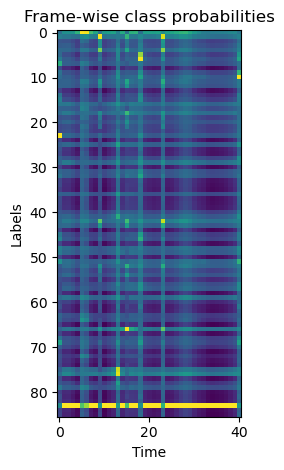

In [26]:
def plot_emission(emission):
    fig, ax = plt.subplots()
    ax.imshow(emission.cpu().T)
    ax.set_title("Frame-wise class probabilities")
    ax.set_xlabel("Time")
    ax.set_ylabel("Labels")
    fig.tight_layout()


plot_emission(emission)

## Tokenize the transcript

In [27]:
DICTIONARY = ga_processor.tokenizer.get_vocab()
#LABELS = bundle.get_labels(star=None)
#for k, v in DICTIONARY.items():
#    print(f"{k}: {v}")

In [28]:
idx2token = {v: k for k, v in DICTIONARY.items()}

In [29]:
tokenized_transcript = [DICTIONARY[phon] for phon in transcript]

for t in tokenized_transcript:
    print(t, end=" ")
print()
for t in transcript:
    print(t, end=" ")

23 1 76 66 6 66 10 
k a ɾˠ ə bˠ ə d̪ˠ 

## computing alignments
frame level alignment calculation using TorchAudio forced alignment API

In [30]:
def align(emission, tokens):
    targets = torch.tensor([tokens], dtype=torch.int32, device=device)
    alignments, scores = F.forced_align(emission, targets, blank=0)

    alignments, scores = alignments[0], scores[0]  # remove batch dimension for simplicity
    scores = scores.exp()  # convert back to probability
    return alignments, scores


aligned_tokens, alignment_scores = align(emission, tokenized_transcript)

In [31]:
for i, (ali, score) in enumerate(zip(aligned_tokens, alignment_scores)):
    #print(idx2token[ali.item()])
    print(f"{i:3d}:\t{ali:2d} [{idx2token[ali.item()]}], {score:.3f}")

  0:	23 [k], 0.978
  1:	 0 [|], 0.001
  2:	 0 [|], 0.001
  3:	 0 [|], 0.001
  4:	 0 [|], 0.009
  5:	 0 [|], 0.954
  6:	 0 [|], 0.851
  7:	 0 [|], 0.019
  8:	 0 [|], 0.004
  9:	 1 [a], 0.878
 10:	 0 [|], 0.002
 11:	 0 [|], 0.003
 12:	 0 [|], 0.004
 13:	76 [ɾˠ], 0.585
 14:	 0 [|], 0.006
 15:	66 [ə], 0.908
 16:	 0 [|], 0.008
 17:	 0 [|], 0.010
 18:	 6 [bˠ], 0.823
 19:	 0 [|], 0.003
 20:	 0 [|], 0.003
 21:	 0 [|], 0.003
 22:	 0 [|], 0.004
 23:	66 [ə], 0.038
 24:	 0 [|], 0.003
 25:	 0 [|], 0.004
 26:	 0 [|], 0.006
 27:	 0 [|], 0.009
 28:	 0 [|], 0.011
 29:	 0 [|], 0.005
 30:	 0 [|], 0.002
 31:	 0 [|], 0.001
 32:	 0 [|], 0.000
 33:	 0 [|], 0.000
 34:	 0 [|], 0.000
 35:	 0 [|], 0.000
 36:	 0 [|], 0.000
 37:	 0 [|], 0.001
 38:	 0 [|], 0.001
 39:	 0 [|], 0.001
 40:	10 [d̪ˠ], 0.940


Great! now we have frame-level alignments. this is all we need for both calculating gibbs entropy and GOP

### token level alignment

In [32]:
token_spans = F.merge_tokens(aligned_tokens, alignment_scores)

print("Token\tTime\tScore")
for s in token_spans:
    print(f"{idx2token[s.token]}\t[{s.start:3d}, {s.end:3d})\t{s.score:.2f}")

Token	Time	Score
k	[  0,   1)	0.98
a	[  9,  10)	0.88
ɾˠ	[ 13,  14)	0.58
ə	[ 15,  16)	0.91
bˠ	[ 18,  19)	0.82
ə	[ 23,  24)	0.04
d̪ˠ	[ 40,  41)	0.94


In [ ]:
import sys
sys.path.insert(0, str(PROJECT_ROOT / 'scripts' / 'asr_system' / 'ensemble'))
from ensemble import (
    # confidence functions
    frame_gibbs_confidence, frame_tsallis_confidence, frame_prob_confidence,
    # span helpers
    span_confidence, best_phone_in_span,
    # russian vocab
    build_ru_ipa_dict, build_pal_set, is_palatalized,
    # main ensemble
    spanwise_ensemble,
)
from functools import partial

In [ ]:
ru_ipa_dict = build_ru_ipa_dict(ru_processor)
pal_set = build_pal_set(ga_processor, ru_ipa_dict)

# testing

In [50]:
sample

{'audio': {'path': 'carbad.wav',
  'array': array([0., 0., 0., ..., 0., 0., 0.], shape=(13440,)),
  'sampling_rate': 16000},
 'phonetic': 'k a ɾˠ ə bˠ ə d̪ˠ',
 'English ASR transcriptions': 'ʌɾəbʌd',
 'synthetic_audio_path': {'path': '0.mp3',
  'array': array([ 3.18323146e-12,  2.27373675e-12, -9.54969437e-12, ...,
          8.29194323e-06, -2.34242179e-06, -2.22762756e-05], shape=(11136,)),
  'sampling_rate': 16000}}

In [52]:
# choose word
waveform = sample['audio']['array']
transcript = sample['phonetic'].split()

In [66]:
from functools import partial

gibbs_res   = spanwise_ensemble(waveform, transcript, 
                              ga_processor, ga_model,
                              en_processor, en_model,
                              ru_processor, ru_model,
                              ru_ipa_dict, 
                              conf_func=frame_gibbs_confidence)
prob_res    = spanwise_ensemble(waveform, transcript, 
                              ga_processor, ga_model,
                              en_processor, en_model,
                              ru_processor, ru_model,
                              ru_ipa_dict, 
                              conf_func=frame_prob_confidence)
tsallis_res = spanwise_ensemble(waveform, transcript, 
                              ga_processor, ga_model,
                              en_processor, en_model,
                              ru_processor, ru_model,
                              ru_ipa_dict, 
                              conf_func=partial(frame_tsallis_confidence, alpha=1/3))


In [67]:
gibbs_res

[{'canonical': 'k', 'predicted': 'k', 'winner': 'ga', 'confidence': 0.9608},
 {'canonical': 'a', 'predicted': '|', 'winner': 'en', 'confidence': 0.9991},
 {'canonical': 'ɾˠ', 'predicted': 'ɾ', 'winner': 'en', 'confidence': 0.973},
 {'canonical': 'ə', 'predicted': 'ə', 'winner': 'ga', 'confidence': 0.88},
 {'canonical': 'bˠ', 'predicted': '|', 'winner': 'en', 'confidence': 0.8281},
 {'canonical': 'ə', 'predicted': 'ʌ', 'winner': 'en', 'confidence': 0.8905},
 {'canonical': 'd̪ˠ', 'predicted': 'd', 'winner': 'en', 'confidence': 0.951}]

In [68]:
prob_res

[{'canonical': 'k', 'predicted': 'k', 'winner': 'ga', 'confidence': 0.9776},
 {'canonical': 'a', 'predicted': '|', 'winner': 'en', 'confidence': 0.9997},
 {'canonical': 'ɾˠ', 'predicted': 'ɾ', 'winner': 'en', 'confidence': 0.9861},
 {'canonical': 'ə', 'predicted': 'ə', 'winner': 'ga', 'confidence': 0.9082},
 {'canonical': 'bˠ', 'predicted': 'bˠ', 'winner': 'ga', 'confidence': 0.8225},
 {'canonical': 'ə', 'predicted': 'ʌ', 'winner': 'en', 'confidence': 0.9163},
 {'canonical': 'd̪ˠ', 'predicted': 'd', 'winner': 'en', 'confidence': 0.9758}]

In [69]:
tsallis_res

[{'canonical': 'k', 'predicted': 'k', 'winner': 'ga', 'confidence': 0.7769},
 {'canonical': 'a', 'predicted': '|', 'winner': 'en', 'confidence': 0.9452},
 {'canonical': 'ɾˠ', 'predicted': 'ɾ', 'winner': 'en', 'confidence': 0.8026},
 {'canonical': 'ə', 'predicted': 'ə', 'winner': 'ga', 'confidence': 0.7309},
 {'canonical': 'bˠ', 'predicted': '|', 'winner': 'en', 'confidence': 0.7541},
 {'canonical': 'ə', 'predicted': 'ʌ', 'winner': 'en', 'confidence': 0.7138},
 {'canonical': 'd̪ˠ', 'predicted': 'd', 'winner': 'en', 'confidence': 0.7304}]